<a href="https://colab.research.google.com/github/Al3x4ndra/Perceptron-ML/blob/main/DefeitosPecas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Acurácia (treino): 1.0
Acurácia (teste): 1.0


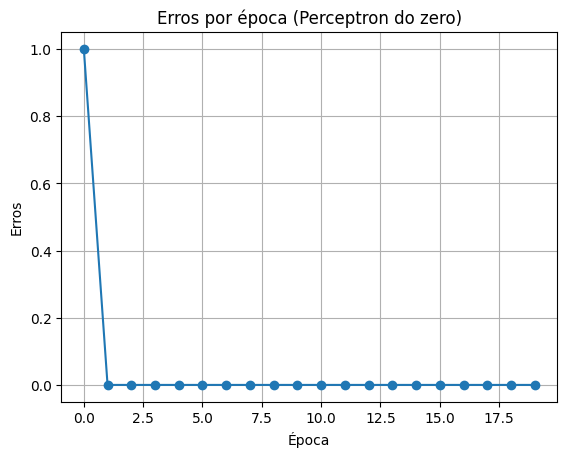

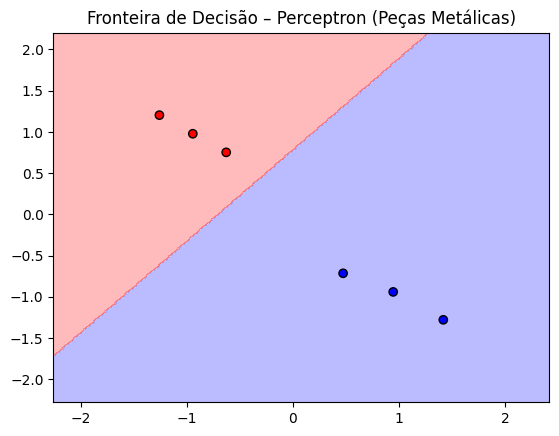

Peça 1: BOA
Peça 2: DEFEITUOSA


In [2]:
# ============================================================
# PERCEPTRON – DETECÇÃO DE DEFEITOS EM PEÇAS METÁLICAS
# Rugosidade (µm) e Refletância (%)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# -------------------------------------
# 1) Criar dataset (simulado)
# -------------------------------------

# [rugosidade, refletancia]
X = np.array([
    [1.1, 87],
    [1.3, 85],
    [1.5, 83],
    [2.2, 70],
    [2.5, 68],
    [2.8, 65],
])

# Classes: +1 = boa ; -1 = defeituosa
y = np.array([+1, +1, +1, -1, -1, -1])


# -------------------------------
# 2) Padronização
# -------------------------------

sc = StandardScaler()
X = sc.fit_transform(X)


# -------------------------------
# 3) Dividir treino/teste
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


# ---------------------------------------------
# 4) Perceptron do zero
# ---------------------------------------------

class PerceptronScratch:
    def __init__(self, lr=0.01, epochs=50):
        self.lr = lr
        self.epochs = epochs
        self.errors = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0

        for _ in range(self.epochs):
            error_count = 0
            for xi, yi in zip(X, y):
                y_pred = np.sign(np.dot(self.w, xi) + self.b)

                # Corrige caso sign retorne 0
                if y_pred == 0:
                    y_pred = 1

                # Regra clássica: atualiza apenas quando ERRA
                if yi != y_pred:
                    self.w += self.lr * yi * xi
                    self.b += self.lr * yi
                    error_count += 1

            self.errors.append(error_count)

    def predict(self, X):
        linear = np.dot(X, self.w) + self.b
        return np.where(linear >= 0, 1, -1)


# -------------------------------
# 5) Treinar modelo
# -------------------------------

model = PerceptronScratch(lr=0.1, epochs=20)
model.fit(X_train, y_train)

pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

print("Acurácia (treino):", accuracy_score(y_train, pred_train))
print("Acurácia (teste):", accuracy_score(y_test, pred_test))


# ------------------------------------------
# 6) Gráfico de erros por época
# ------------------------------------------

plt.plot(model.errors, marker='o')
plt.title("Erros por época (Perceptron do zero)")
plt.xlabel("Época")
plt.ylabel("Erros")
plt.grid(True)
plt.savefig("erros_pecas.png", dpi=300)
plt.show()


# ------------------------------------------
# 7) Fronteira de decisão
# ------------------------------------------

def plot_decision_boundary(model, X, y, title, filename):
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolor='k')
    plt.title(title)
    plt.savefig(filename, dpi=300)
    plt.show()


plot_decision_boundary(
    model, X, y,
    "Fronteira de Decisão – Perceptron (Peças Metálicas)",
    "fronteira_pecas.png"
)


# ------------------------------------------
# 8) Testar novas peças
# ------------------------------------------

novas_pecas = np.array([
    [1.2, 86],  # boa
    [2.6, 67],  # defeituosa
])

# Aplicar scaler!
novas_pecas_std = sc.transform(novas_pecas)

pred_novas = model.predict(novas_pecas_std)

for i, p in enumerate(pred_novas):
    print(f"Peça {i+1}: {'BOA' if p == 1 else 'DEFEITUOSA'}")